Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Project Description

Business Context:

Rusty Bargain used car sales service is developing an app to attract new customers. The app will allow users to quickly find out the market value of their car using historical data including technical specifications, trim versions, and prices.

Objective:

Build a machine learning model to determine the market value of used cars. The company is particularly interested in:

The quality of the prediction (accuracy)
The speed of the prediction (inference time)
The time required for training

Dataset:

The dataset contains historical car sales data with the following features:

Target variable: Price (in Euros)

Features: DateCrawled, VehicleType, RegistrationYear, Gearbox, Power, Model, Mileage, RegistrationMonth, FuelType, Brand, NotRepaired, DateCreated, NumberOfPictures, PostalCode, LastSeen

Methodology:

I performed:
Data Analysis & Preprocessing: 

Explored and cleand the dataset, handled missing values, and prepared features

Model Development: Trained and compared multiple models including:

Linear Regression (sanity check)

Random Forest with hyperparameter tuning

LightGBM with hyperparameter tuning

Model Evaluation: Compared models using RMSE metric and analyzed training/prediction speeds

Success Metrics:

RMSE (Root Mean Square Error) for prediction quality

Training time and prediction speed analysis


## Data preparation

### EDA

In [1]:
# importing the libraries:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import time
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv("/datasets/car_data.csv")

In [3]:
display(data.head())
data.info()
display(data.describe())
data.shape

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


(354369, 16)

In [4]:
# Get null counts and sort from smallest to largest
null_counts = data.isnull().sum().sort_values()
print("Null counts (smallest to largest):")
print(null_counts)

Null counts (smallest to largest):
DateCrawled              0
Price                    0
RegistrationYear         0
Power                    0
Mileage                  0
RegistrationMonth        0
Brand                    0
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
Model                19705
Gearbox              19833
FuelType             32895
VehicleType          37490
NotRepaired          71154
dtype: int64


In [5]:
# Get non-null counts and sort from smallest to largest
non_null_counts = data.count().sort_values()
print("Non-null counts (smallest to largest):")
print(non_null_counts)

Non-null counts (smallest to largest):
NotRepaired          283215
VehicleType          316879
FuelType             321474
Gearbox              334536
Model                334664
DateCrawled          354369
Price                354369
RegistrationYear     354369
Power                354369
Mileage              354369
RegistrationMonth    354369
Brand                354369
DateCreated          354369
NumberOfPictures     354369
PostalCode           354369
LastSeen             354369
dtype: int64


In [6]:
# Create a summary DataFrame and sort by non-null count
summary = pd.DataFrame({
    'Non-Null Count': data.count(),
    'Null Count': data.isnull().sum(),
    'Data Type': data.dtypes
}).sort_values('Non-Null Count')

print(summary)

                   Non-Null Count  Null Count Data Type
NotRepaired                283215       71154    object
VehicleType                316879       37490    object
FuelType                   321474       32895    object
Gearbox                    334536       19833    object
Model                      334664       19705    object
DateCrawled                354369           0    object
Price                      354369           0     int64
RegistrationYear           354369           0     int64
Power                      354369           0     int64
Mileage                    354369           0     int64
RegistrationMonth          354369           0     int64
Brand                      354369           0    object
DateCreated                354369           0    object
NumberOfPictures           354369           0     int64
PostalCode                 354369           0     int64
LastSeen                   354369           0    object


In [7]:
# Checking the percentage of missing data for each column
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_info = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print(missing_info[missing_info['Missing_Count'] > 0])

             Missing_Count  Missing_Percentage
NotRepaired          71154           20.079070
VehicleType          37490           10.579368
FuelType             32895            9.282697
Gearbox              19833            5.596709
Model                19705            5.560588


In [8]:
# Checking dataset size before cleaning:
print(f"Original dataset size: {len(data)}")

# Dropping rows with any missing values:
# data_nonnull = data.dropna()

# Replacing rows with missing values withh "unkown":
data_nonnull = data.copy()

categorical_columns = ['VehicleType', 'Gearbox', 'FuelType', 'Brand', 'Model', 'NotRepaired']

for col in categorical_columns:
    data_nonnull[col] = data_nonnull[col].fillna('unknown')


print(f"Dataset size after fixing incomplete records: {len(data_nonnull)}")
print(f"Records removed: {len(data) - len(data_nonnull)}")
print(f"Percentage of data retained: {(len(data_nonnull)/len(data))*100:.1f}%")


Original dataset size: 354369
Dataset size after fixing incomplete records: 354369
Records removed: 0
Percentage of data retained: 100.0%


In [9]:
# As per @Dot generally, retaining about 70% of your data while ensuring complete records is often a good trade-off. I will proceed with dropping all missing records 

In [10]:
data_nonnull.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


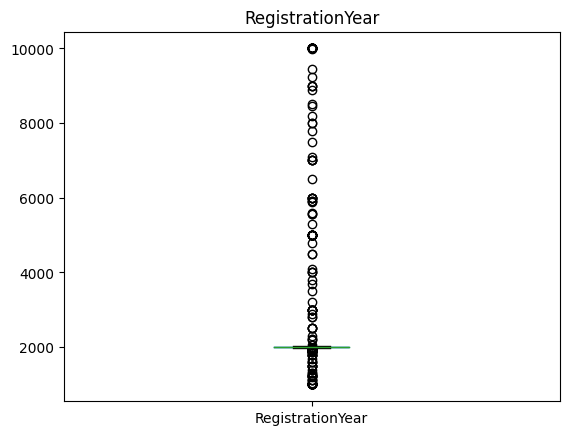

In [11]:

data_nonnull[['RegistrationYear']].plot.box() #	Power	Registration Month	
plt.title('RegistrationYear')
plt.show()


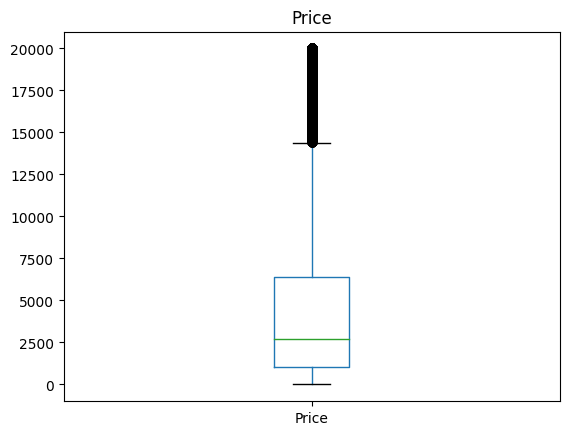

In [12]:
data_nonnull[['Price']].plot.box() # Price	RegistrationYear Power	Mileage	Registration Month	
plt.title('Price')
plt.show()

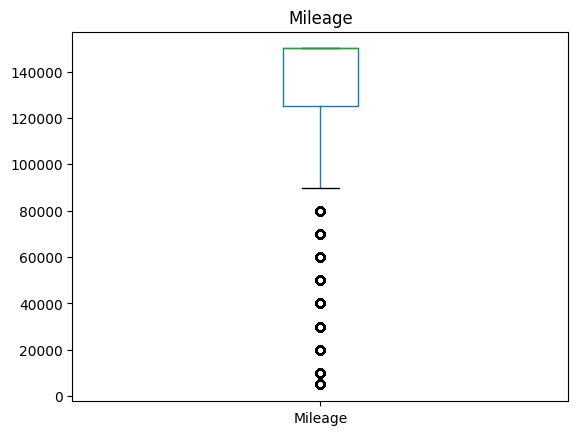

In [13]:
data_nonnull[['Mileage']].plot.box() 
plt.title('Mileage')
plt.show()

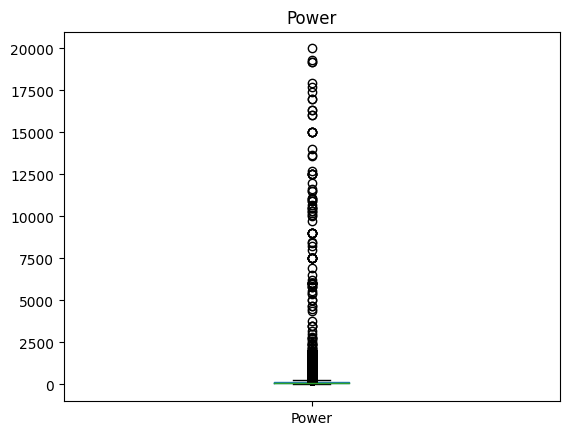

In [14]:
data_nonnull[['Power']].plot.box() # Price	RegistrationYear Power	Mileage	RegistrationMonth	
plt.title('Power')
plt.show()

In [15]:
#Handling Outliers:

def handle_price_outliers(df, column):
    df[column] = df[column].clip(100, 50000)
    return df

def handle_power_outliers(df, column):
    df = df[df[column] <= 1000]
    return df

def handle_registration_year_outliers(df, column):
    current_year = pd.to_datetime('today').year
    df = df[df[column] >= 1960]
    df[column] = df[column].clip(upper=current_year)
    return df

def no_outlier_handling(df, column):
       return df

outlier_conditions = {
    'Price': handle_price_outliers,
    'Power': handle_power_outliers,
    'Mileage': no_outlier_handling, 
    'RegistrationYear': handle_registration_year_outliers,
    # Add other columns and handling functions here
}

def apply_custom_outlier_handling(df, conditions):
    for column, handler in conditions.items():
        if column in df.columns: # Check if the column exists
            df = handler(df, column)
    return df

# Apply the custom outlier handling
data_nonnull = apply_custom_outlier_handling(data_nonnull, outlier_conditions)

print(data_nonnull.describe())  # Check the results
print(f"DataFrame shape after handling: {data_nonnull.shape}")  

               Price  RegistrationYear          Power        Mileage  \
count  353651.000000     353651.000000  353651.000000  353651.000000   
mean     4420.455209       2003.157073     106.708334  128297.728552   
std      4509.140234          7.234850      64.191885   37789.275069   
min       100.000000       1960.000000       0.000000    5000.000000   
25%      1050.000000       1999.000000      69.000000  125000.000000   
50%      2700.000000       2003.000000     105.000000  150000.000000   
75%      6400.000000       2008.000000     141.000000  150000.000000   
max     20000.000000       2025.000000    1000.000000  150000.000000   

       RegistrationMonth  NumberOfPictures     PostalCode  
count      353651.000000          353651.0  353651.000000  
mean            5.717942               0.0   50517.537154  
std             3.725342               0.0   25780.530258  
min             0.000000               0.0    1067.000000  
25%             3.000000               0.0   30165.

/tmp/ipykernel_60/1575357812.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(upper=current_year)


### Data Preprocessing

In [16]:
# Features to exclude:
features_to_drop = [
    'DateCrawled',      # Jaaaust metadata, not predictive
    'DateCreated',      # Just metadata, not predictive  
    'LastSeen',         # User activity, not car-related
    'PostalCode',       # Too specific, might cause overfitting
    'NumberOfPictures'  # Marketing feature, not car quality
]

# Dropping the features:
data_nonnull = data_nonnull.drop(columns=features_to_drop)

data_nonnull.info()
data_nonnull.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 353651 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Price              353651 non-null  int64 
 1   VehicleType        353651 non-null  object
 2   RegistrationYear   353651 non-null  int64 
 3   Gearbox            353651 non-null  object
 4   Power              353651 non-null  int64 
 5   Model              353651 non-null  object
 6   Mileage            353651 non-null  int64 
 7   RegistrationMonth  353651 non-null  int64 
 8   FuelType           353651 non-null  object
 9   Brand              353651 non-null  object
 10  NotRepaired        353651 non-null  object
dtypes: int64(5), object(6)
memory usage: 32.4+ MB


['Price',
 'VehicleType',
 'RegistrationYear',
 'Gearbox',
 'Power',
 'Model',
 'Mileage',
 'RegistrationMonth',
 'FuelType',
 'Brand',
 'NotRepaired']

In [17]:
# displaying the object columns list:
categorical_cols = data_nonnull.select_dtypes(include=['object'])
display(categorical_cols)

,VehicleType,Gearbox,Model,FuelType,Brand,NotRepaired
0,unknown,manual,golf,petrol,volkswagen,unknown
1,coupe,manual,unknown,gasoline,audi,yes
2,suv,auto,grand,gasoline,jeep,unknown
3,small,manual,golf,petrol,volkswagen,no
4,small,manual,fabia,gasoline,skoda,no
...,...,...,...,...,...,...
354364,unknown,manual,colt,petrol,mitsubishi,yes
354365,unknown,unknown,unknown,unknown,sonstige_autos,unknown
354366,convertible,auto,fortwo,petrol,smart,no
354367,bus,manual,transporter,gasoline,volkswagen,no


In [18]:
# Separating the features columns in a categorical and a numerical set: 
categorical_features = data_nonnull.select_dtypes(include= 'object').columns
numerical_features = data_nonnull.select_dtypes(include = ['int64', 'float64']).columns
X_categorical = data_nonnull[categorical_features]
X_numerical = data_nonnull[numerical_features]

In [19]:
# Encoding the categorical set:
X_encoded = X_categorical.copy()

for col in categorical_cols:
    le = LabelEncoder() 
    X_encoded[col] = le.fit_transform(X_categorical[col])

In [20]:
# Concatanating the numerical and categorical features in X_combined dataframe:
X_combined = pd.concat([X_numerical, X_encoded], axis=1)
display(X_combined.head())

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,VehicleType,Gearbox,Model,FuelType,Brand,NotRepaired
0,480,1993,0,150000,0,7,1,116,6,38,1
1,18300,2011,190,125000,5,2,1,228,2,1,2
2,9800,2004,163,125000,8,6,0,117,2,14,1
3,1500,2001,75,150000,6,5,1,116,6,38,0
4,3600,2008,69,90000,7,5,1,101,2,31,0


In [21]:
# Splitting the data for the Linear Regression and Random Forrest Regression Models:
X = X_combined.drop(columns = ["Price"])
y = data_nonnull["Price"]

# First split: separating test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42
)

# Second split: dividing remaining data into train and validation ()
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, 
    test_size=0.176,  
    random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_valid)} samples") 
print(f"Test set: {len(X_test)} samples")



Training set: 247696 samples
Validation set: 52907 samples
Test set: 53048 samples


In [22]:
# scaling and transforming the data:
scaler = StandardScaler()
scaler.fit(X_train)  # fit only on training data!
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform (X_valid)
X_test_scaled = scaler.transform(X_test) # transform all training, valid and test data sets

# converting the sets to a DataFrame:

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled_df = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


# Checking the shape and type:

print(f" X_train_scaled_df Shape: {X_train_scaled_df.shape}")
print(f" X_train_scaled_df Type: {type(X_train_scaled_df)}")

print(f" X_valid_scaled_df Shape: {X_valid_scaled_df.shape}")
print(f" X_valid_scaled_df Type: {type(X_valid_scaled_df)}")

print(f" X_test_scaled_df Shape: {X_test_scaled_df.shape}")
print(f" X_test_scaled_df Type: {type(X_test_scaled_df)}")

 X_train_scaled_df Shape: (247696, 10)
 X_train_scaled_df Type: <class 'pandas.core.frame.DataFrame'>
 X_valid_scaled_df Shape: (52907, 10)
 X_valid_scaled_df Type: <class 'pandas.core.frame.DataFrame'>
 X_test_scaled_df Shape: (53048, 10)
 X_test_scaled_df Type: <class 'pandas.core.frame.DataFrame'>


## Model training

### Linear Regression Model

In [23]:
# fitting the model:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled_df, y_train)
y_predict = lr_model.predict(X_valid_scaled_df)

#calculating rmse
rmse = np.sqrt(mean_squared_error(y_valid, y_predict))
print (f"RMSE: {rmse}")

RMSE: 3131.205620778527


In [24]:
# Label Encoded and Scaled sets: 

"""X_train_scaled_df Shape: (172167, 11)
 X_train_scaled_df Type: <class 'pandas.core.frame.DataFrame'>
 X_valid_scaled_df Shape: (36774, 11)
 X_valid_scaled_df Type: <class 'pandas.core.frame.DataFrame'>
 X_test_scaled_df Shape: (36873, 11)
 X_test_scaled_df Type: <class 'pandas.core.frame.DataFrame'> """

# Defining parameter grid for Random Forest:

param_grid = {
    'n_estimators': [20, 50, 75],
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [2, 5],
    }

# Random Forest model:
rf_model = RandomForestRegressor(random_state=42)

# GridSearchCV:
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=2,
    n_jobs=-1,
)

# Fitting the grid search:
rf_grid_search.fit(X_train_scaled_df, y_train)

# Getting the best parameters:
best_params_rf = rf_grid_search.best_params_
print("Best parameters:", best_params_rf)

# Getting the best model 
best_model_rf = rf_grid_search.best_estimator_
print("Best model:", best_model_rf)

# Predicting on the model:
y_predict = best_model_rf.predict(X_valid_scaled_df)

#Calculating RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_predict))
print(f"RMSE: {rmse}")


Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 75}
Best model: RandomForestRegressor(min_samples_split=5, n_estimators=75, random_state=42)
RMSE: 1735.067782968463


#### LightGBM 

In [25]:


# Defining parameter grid:

param_grid = {
    'max_depth': [2,5,10],
    'n_estimators': [25, 50, 75, 100],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2]
}


# Light GBM model:
lgb_model = lgb.LGBMRegressor(random_state=42)

# GridSearchCV:
lgb_grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=2,
    n_jobs=-1,
)

# Fitting the grid search:
lgb_grid_search.fit(X_train_scaled_df, y_train)

# Getting the best parameters:
best_params_lgb = lgb_grid_search.best_params_
print("Best parameters:", best_params_lgb)

# Getting the best model 
best_model_lgb = lgb_grid_search.best_estimator_
print("Best Model:", best_model_lgb)

# Predicting on the model:
y_predict = best_model_lgb.predict(X_valid_scaled_df)

#Calculating RMSE

rmse = np.sqrt(mean_squared_error(y_valid, y_predict))
print(f"RMSE: {rmse}")



Best parameters: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 100}
Best Model: LGBMRegressor(learning_rate=0.2, max_depth=10, random_state=42)
RMSE: 1785.6172065446015


## Model analysis

In [26]:


# List of models to test
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42)
}

# Loopping through all models
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Measure training time
    start_time = time.time()
    model.fit(X_train_scaled_df, y_train)
    training_time = time.time() - start_time
    
    # Measure prediction time
    start_time = time.time()
    y_pred = model.predict(X_valid_scaled_df)
    prediction_time = time.time() - start_time    
   
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Prediction Time: {prediction_time:.4f} seconds")


Training Linear Regression...
Training Time: 0.04 seconds
Prediction Time: 0.0801 seconds

Training Random Forest...
Training Time: 59.58 seconds
Prediction Time: 2.1768 seconds

Training LightGBM...
Training Time: 2.24 seconds
Prediction Time: 0.2080 seconds


### Model Analyses Conclusion

The model with the best RMSE score and best training/prediction time is the LightGBM best_model_lgb

### Using the best_model_lgb to predict on the y_test set

In [27]:
#Combining the training and validation data
X_train_full = pd.concat((X_train_scaled_df, X_valid_scaled_df), axis=0)
y_train_full = pd.concat((y_train, y_valid), axis=0)

best_model = lgb.LGBMRegressor(random_state=42, learning_rate = 0.2, max_depth =10, n_estimators = 100)

# Training and making preditions with the best model:
best_model.fit(X_train_full, y_train_full)
y_predict_best_model = best_model.predict(X_test_scaled_df)

# Calculating RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_predict_best_model))
print(f"RMSE: {rmse}")

RMSE: 1778.666718114067


In [28]:
# Conclusion
# The Model is performing well on mew data. 